In [48]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [49]:
import pickle, h5py, os, glob
import numpy as np
import pandas as pd
import tensorflow as tf
import tensorflow_probability as tfp
import jax.numpy as jnp
import matplotlib.pyplot as plt
from tqdm import tqdm

from sobol_seq import i4_sobol

# preprocessing
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# inference
from msi.gaussian_mixture.gaussian_mixture_model import ConditionalGMM

from msi.gaussian_likelihood.dense_emulator import DenseEmulator

from pzflow import Flow
from pzflow.bijectors import ShiftBounds, RollingSplineCoupling, Chain
from pzflow.distributions import CentBeta13
from sklearn.model_selection import train_test_split

# utils
from msi.utils import input_output, plotting, mcmc
from msfm.utils import prior, parameters, files

In [50]:
conf = files.load_config()

with h5py.File("/global/homes/a/athomsen/multiprobe-simulation-forward-model/data/CosmoGridV1_metainfo.h5", "r") as f:
    cosmogrid_info = f["parameters/grid"][:]
info_Om = cosmogrid_info["Om"]

out_dir = "/pscratch/sd/a/athomsen/run_files/v3/power_spectra"

# data loading

## clustering only

In [51]:
params = ["Om", "s8", "bg", "n_bg"]
probe_label = "clustering"

clustering_file = "/global/cfs/cdirs/des/athomsen/power_spectra/v3/cls_clustering.h5"

with h5py.File(clustering_file, "r") as f:
    bin_lengths = f["bin_lengths"][:]
    
    fidu_index = f["fidu/index"][:]
    fidu_cls = f["fidu/cls"][:]
    
    grid_theta = f["grid/theta"][:]
    grid_cls = f["grid/cls"][:]
    
# only select the right parameters
grid_theta = grid_theta[:,[0, 1, 8, 9]]

## lensing only

In [52]:
# params = ["Om", "s8", "Aia", "n_Aia"]
# probe_label = "lensing"

# lensing_file = "/global/cfs/cdirs/des/athomsen/power_spectra/v3/cls_lensing.h5"

# with h5py.File(lensing_file, "r") as f:
#     bin_lengths = f["bin_lengths"][:]

#     fidu_index = f["fidu/index"][:]
#     fidu_cls = f["fidu/cls"][:]
    
#     grid_theta = f["grid/theta"][:]
#     grid_cls = f["grid/cls"][:]

## general

In [53]:
n_params = len(params)

print(f"fidu_index.shape = {fidu_index.shape}")
print(f"fidu_cls.shape = {fidu_cls.shape}\n")

print(f"grid_theta.shape = {grid_theta.shape}")
print(f"grid_cls.shape = {grid_cls.shape}")

assert fidu_index.shape[0] == fidu_cls.shape[0]
assert grid_theta.shape[0] == grid_cls.shape[0]
assert grid_cls.shape[1] == fidu_cls.shape[1]

fidu_index.shape = (750,)
fidu_cls.shape = (750, 178)

grid_theta.shape = (39984, 4)
grid_cls.shape = (39984, 178)


### plot power spectra

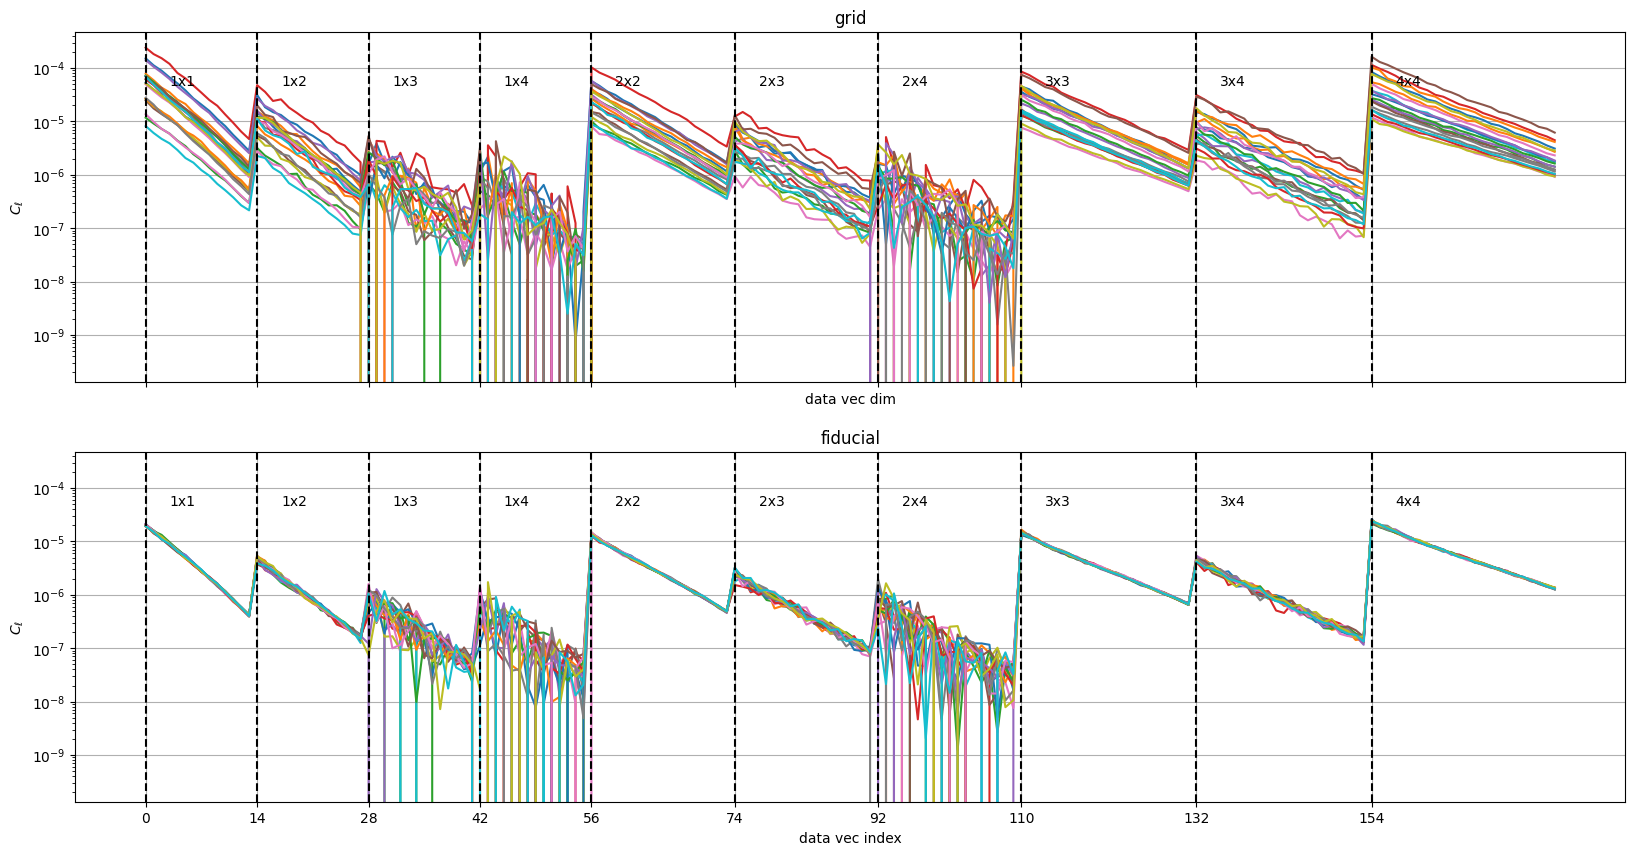

In [54]:
# grid
random_indices = np.random.choice(np.arange(grid_cls.shape[0]), 20)

fig, ax = plt.subplots(figsize=(20,10), nrows=2, sharex=True, sharey=True)

for i in random_indices:    
    ax[0].plot(grid_cls[i])
        
ax[0].set(xscale="linear", yscale="log", title=r"grid", xlabel="data vec dim", ylabel=r"$C_\ell$")
ax[0].grid(True)

# fiducial
random_indices = np.random.choice(np.arange(fidu_cls.shape[0]), 20)

for i in random_indices:    
    ax[1].plot(fidu_cls[i])

ax[1].set(title=r"fiducial", xlabel="data vec index", ylabel=r"$C_\ell$")
ax[1].grid(True)

# cosmetics
x = 0
labels = ["1x1", "1x2", "1x3", "1x4", "2x2", "2x3", "2x4", "3x3", "3x4", "4x4"]
ticks = []
for i, n in enumerate(bin_lengths):
    ax[0].axvline(x, color="k", linestyle="--")
    ax[1].axvline(x, color="k", linestyle="--")
        
    ax[0].text(x + 3, 0.1*ax[0].get_ylim()[1], labels[i])
    ax[1].text(x + 3, 0.1*ax[1].get_ylim()[1], labels[i])

    ticks.append(x)
    x += n
    
ax[0].set_xticks(ticks)
ax[1].set_xticks(ticks);

# remove the cross bins

In [55]:
print(grid_cls.shape)
print(fidu_cls.shape)

(39984, 178)
(750, 178)


In [56]:
# bin_uppers = []
# bin_upper = 0
# for i, n in enumerate(bin_lengths):
#     bin_upper += n
#     bin_uppers.append(bin_upper)

# print(bin_uppers)

In [57]:
# counter = 0
# for i in range(4):
#     for j in range(4):
#         if i <= j:
#             counter += 1
            
#             print(i+1,j+1)

In [58]:
# assert grid_cls.shape[-1] == fidu_cls.shape[-1]
# n_summary = grid_cls.shape[-1]

# mask = np.zeros(n_summary, dtype=bool)
# mask[:14] = 1
# mask[56:74] = 1
# mask[110:132] = 1
# mask[154:] = 1

# grid_cls = grid_cls[:,mask]
# fidu_cls = fidu_cls[:,mask]

# # grid
# random_indices = np.random.choice(np.arange(grid_cls.shape[0]), 20)

# fig, ax = plt.subplots(figsize=(20,10), nrows=2, sharex=True, sharey=True)

# for i in random_indices:    
#     ax[0].plot(grid_cls[i])
        
# ax[0].set(xscale="linear", yscale="log", title=r"grid", xlabel="data vec dim", ylabel=r"$C_\ell$")
# ax[0].grid(True)

# # fiducial
# random_indices = np.random.choice(np.arange(fidu_cls.shape[0]), 20)

# for i in random_indices:    
#     ax[1].plot(fidu_cls[i])

# ax[1].set(title=r"fiducial", xlabel="data vec index", ylabel=r"$C_\ell$")
# ax[1].grid(True)


### observation

In [59]:
# obs_cls = np.median(fidu_cls, axis=0, keepdims=True)
obs_cls = fidu_cls[0,:][np.newaxis]
print(obs_cls.shape)

(1, 178)


### preprocessing

In [60]:
# PCA
pca = PCA(n_components=10)

grid_compressed_cls = pca.fit_transform(grid_cls)
fidu_compressed_cls = pca.transform(fidu_cls)
obs_compressed_cls = pca.transform(obs_cls)

print(f"grid shape before compression: {grid_cls.shape}")
print(f"grid shape after compression: {grid_compressed_cls.shape}")

# StandardScaler
scaler = StandardScaler()

grid_compressed_cls = scaler.fit_transform(grid_compressed_cls)
fidu_compressed_cls = scaler.transform(fidu_compressed_cls)
obs_compressed_cls = scaler.transform(obs_compressed_cls)

scaler = StandardScaler()

grid_standard_cls = scaler.fit_transform(grid_cls)
fidu_standard_cls = scaler.transform(fidu_cls)
obs_standard_cls = scaler.transform(obs_cls)

grid shape before compression: (39984, 178)
grid shape after compression: (39984, 10)


# inference with normalizing flow

In [61]:
flow_data = grid_compressed_cls
flow_conds = grid_theta
flow_obs = obs_compressed_cls

In [62]:
n_examples = flow_data.shape[0]
n_summaries = flow_data.shape[1]
summary_labels = [f"summary_{i}" for i in range(n_summaries)]

# build data frame
df_total = pd.DataFrame()

for i, summary_label in enumerate(summary_labels):
    df_total[summary_label] = flow_data[:,i]
    
for i, param in enumerate(params):
    df_total[param] = flow_conds[:,i]
    
df_train, df_val = train_test_split(df_total, test_size=0.1)

# repack the observation
obs_df = pd.DataFrame([flow_obs[0]], columns=summary_labels)

Training 100 epochs 
Loss:
(0) 35.0338  34.9504
(1) 7.7727  8.0430
(6) -0.3848  0.0758
(11) -1.1168  -0.6020
(16) -1.6195  -1.0283
(21) 0.4556  0.9513
(26) 1.3957  1.8906
(31) -1.2145  -0.5695
(36) -2.6098  -1.8219
(41) -2.6757  -1.8009
(46) -2.8749  -1.9857
(51) -2.8739  -1.9673
(56) -2.9003  -1.9674
(61) -2.7863  -1.7795
(66) -2.8186  -1.7362
(71) -3.0370  -1.9383
(76) -3.2022  -2.0125
(81) -3.1880  -1.9674
(86) -3.4285  -2.1380
(91) -3.2432  -1.8957
(96) -3.5247  -2.0365
(100) -3.5290  -2.1006


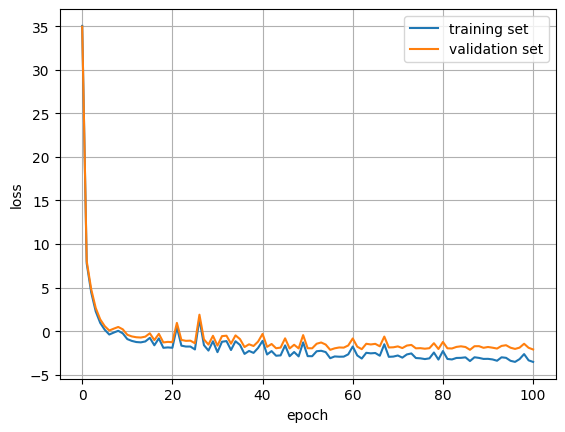

In [63]:
latent = CentBeta13(input_dim=n_summaries, B=5)
bijector = Chain(
    ShiftBounds(jnp.array(df_total[summary_labels].min(axis=0)), jnp.array(df_total[summary_labels].max(axis=0)), B=4),
    RollingSplineCoupling(n_summaries, B=5, n_conditions=n_params, hidden_dim=128),
)

flow = Flow(
    data_columns=summary_labels, 
    conditional_columns=params, 
    latent=latent,
    bijector=bijector,
)

# train
loss_train, loss_val = flow.train(df_train, df_val, verbose=True, epochs=100)

# plot
fig, ax = plt.subplots()
ax.plot(loss_train, label="training set")
ax.plot(loss_val, label="validation set")
ax.set(xlabel="epoch", ylabel="loss")
ax.legend()
ax.grid(True)

23-07-21 07:54:38      mcmc.py INF   Initial values in prior: True 


100%|██████████| 500/500 [04:40<00:00,  1.78it/s]


  0%|          | 0/6 [00:00<?, ?it/s]

  0%|          | 0/6 [00:00<?, ?it/s]

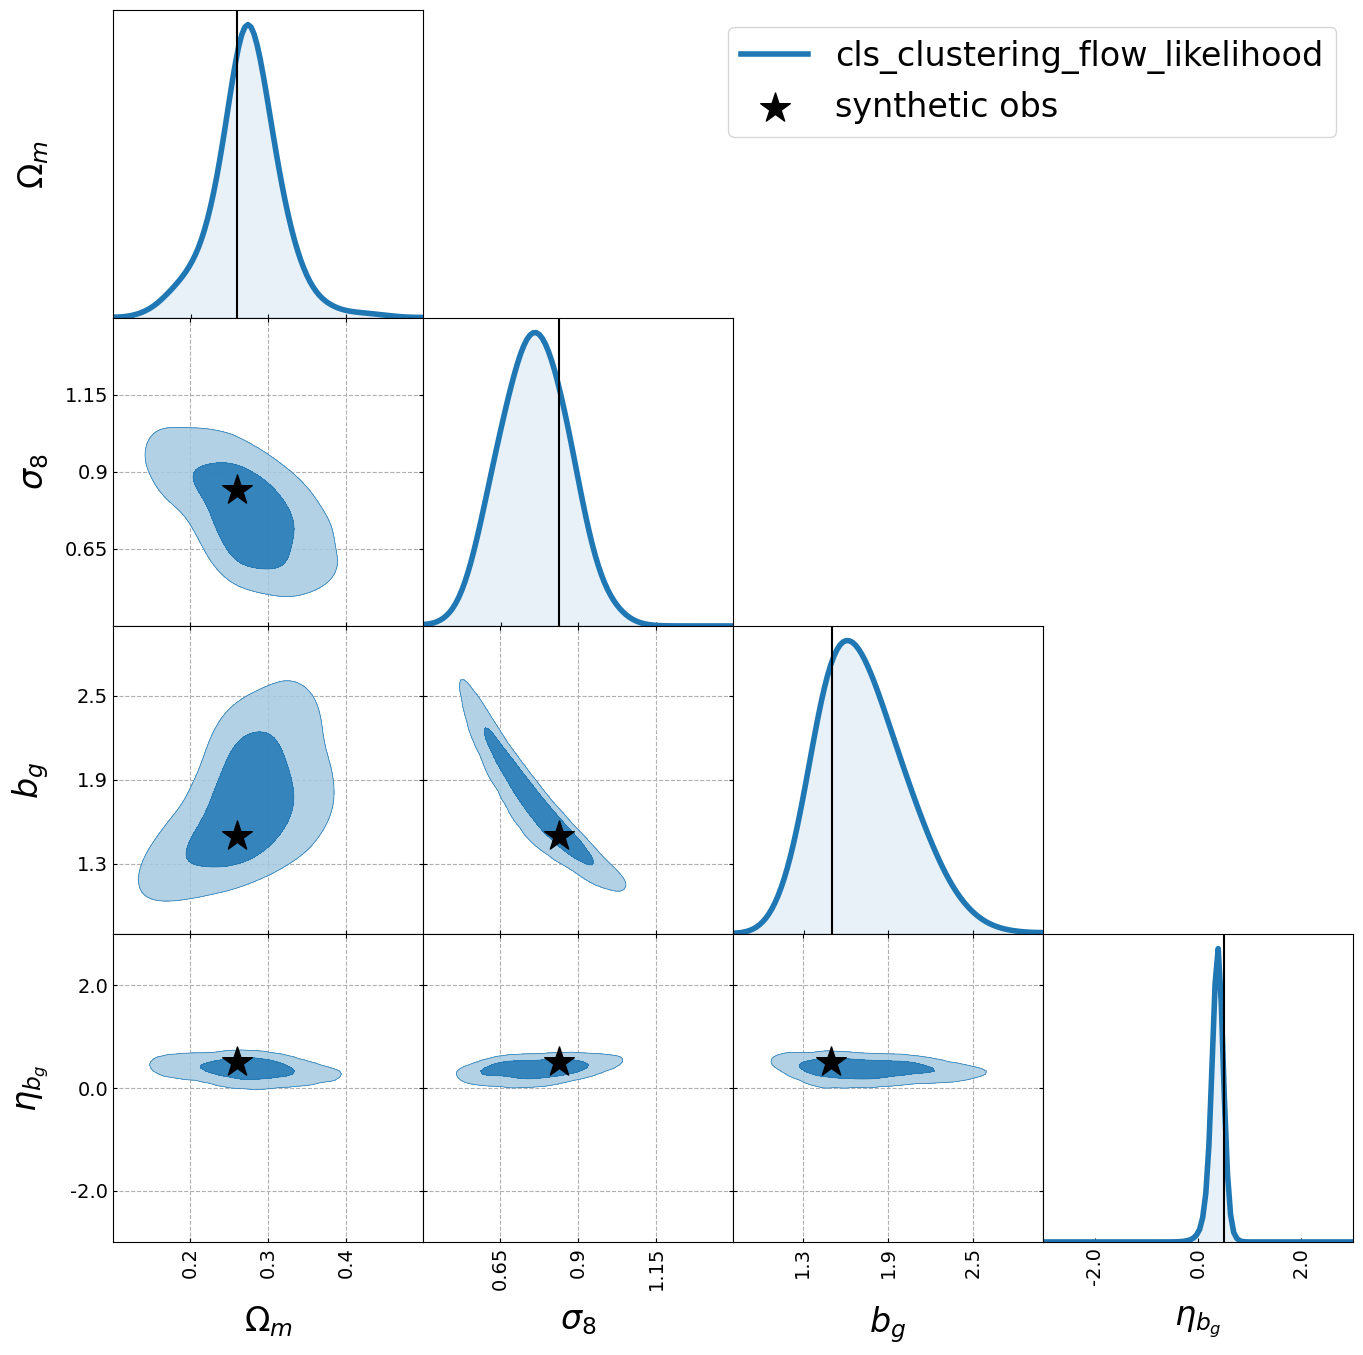

In [64]:
method_label = f"flow_likelihood"
label = "cls_" + probe_label + "_" + method_label# + "_auto"

def log_likelihood(X): 
    # convert to dataframe
    X = pd.DataFrame(X, columns=params)
    X = X.join(obs_df, how="cross")

    # evaluate the normalizing flow
    log_prob = flow.log_prob(X)
    
    # enforce the prior
    log_prob = prior.log_posterior(X.loc[:,params], log_prob, params=params, conf=None)

    return log_prob

chain = mcmc.run_emcee(
    log_likelihood,
    params,
    out_dir=out_dir,
    label=label,
    n_steps=500,
)

plotting.plot_chains(
    chain, 
    params, 
    out_dir=out_dir, 
    labels=label,
)

# inference with mixture of Gaussians

In [27]:
x_gauss_mix = grid_theta

y_gauss_mix = grid_compressed_cls
obs_gauss_mix = obs_compressed_cls

# y_gauss_mix = grid_standard_cls
# obs_gauss_mix = obs_standard_cls

23-07-21 07:41:07 gaussian_mix INF   Created GMM model with n_params = 266504 
Model: "gaussian_mixture_model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 gaussian_noise (GaussianNoi  (None, 4)                0         
 se)                                                             
                                                                 
 dense (Dense)               (None, 256)               1280      
                                                                 
 dropout (Dropout)           (None, 256)               0         
                                                                 
 dense_1 (Dense)             (None, 256)               65792     
                                                                 
 dropout_1 (Dropout)         (None, 256)               0         
                                                                 
 dense_2 (Dense)             (N

epoch:  39%|███▉      | 389/1000 [00:42<01:01,  9.90it/s, loss=-34.3, val_loss=-31.7, lr=0.0001]  

Restoring model weights from the end of the best epoch: 290.


epoch:  39%|███▉      | 390/1000 [00:42<01:02,  9.77it/s, loss=-34.3, val_loss=-29.9, lr=0.0001]

Epoch 390: early stopping


epoch:  39%|███▉      | 390/1000 [00:42<01:07,  9.09it/s, loss=-34.3, val_loss=-29.9, lr=0.0001]

23-07-21 07:41:50 gaussian_mix INF   Finished training 


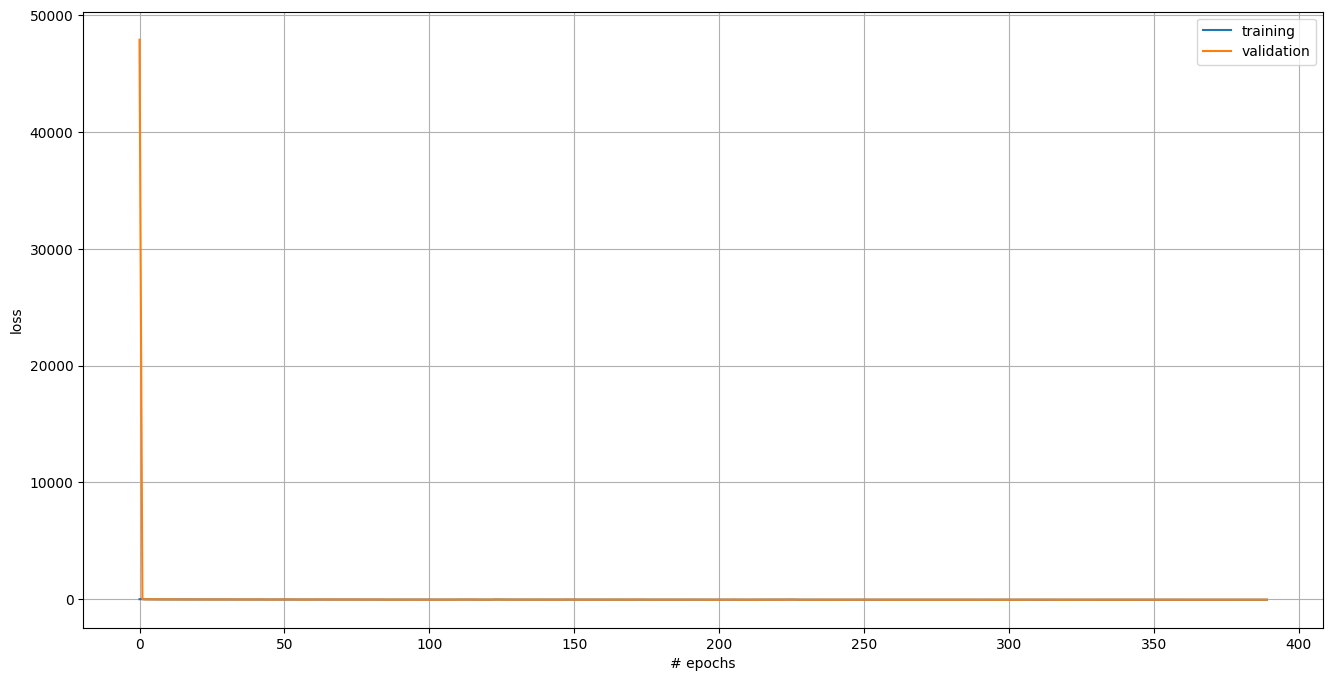

In [28]:
# p(y | x) <=> p(cls | theta)
model = ConditionalGMM(
    # theta
    x_dim=x_gauss_mix.shape[1],
    # cls
    y_dim=y_gauss_mix.shape[1],
    out_dir=None,
    n_gaussians=4,
    u_units=256,
    n_layers=3,
    activation="relu",
    input_noise_sig=0.0,
    tune_hyperparams=False,
)

# training
fit_history = model.fit(
    x=x_gauss_mix,
    y=y_gauss_mix,
    epochs=1000,
    batch_size=2499,
    early_stopping_callback=True,
    learning_rate_callback=True,
)

# plot
fig, ax = plt.subplots(figsize=(16,8))

ax.plot(fit_history.history["loss"], label="training")
ax.plot(fit_history.history["val_loss"], label="validation")

ax.legend()
ax.set(xlabel="# epochs", ylabel="loss", yscale="linear")
ax.grid(True)

23-07-21 07:41:50      mcmc.py INF   Initial values in prior: True 


100%|██████████| 500/500 [01:14<00:00,  6.69it/s]


  0%|          | 0/6 [00:00<?, ?it/s]

  0%|          | 0/6 [00:00<?, ?it/s]

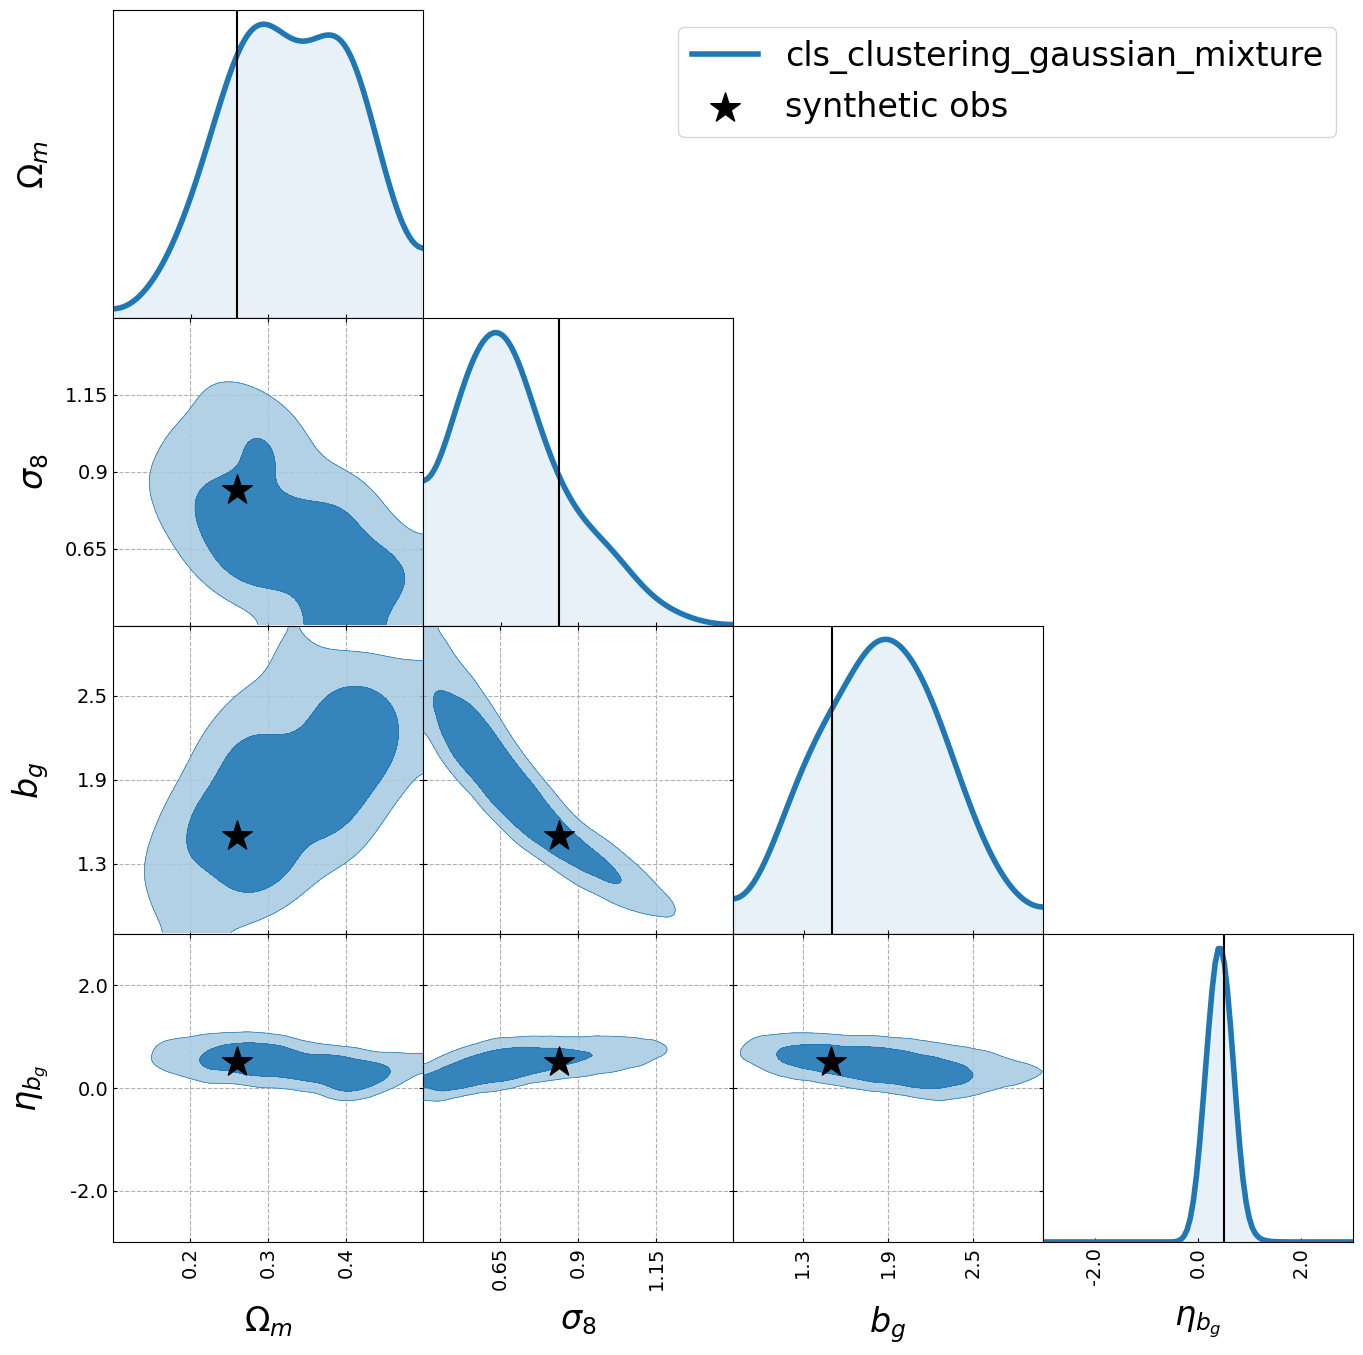

In [29]:
method_label = f"gaussian_mixture"
label = "cls_" + probe_label + "_" + method_label

tf_pred = tf.cast(obs_gauss_mix, dtype=tf.float64)
# tf_pred = tf.cast(obs_cls[np.newaxis,:], dtype=tf.float32)

def log_likelihood(X): 
    # evaluate the normal distribution
    log_prob = model.log_likelihood(X, tf_pred)
    
    # enforce the prior
    log_prob = prior.log_posterior(X, log_prob, params=params, conf=None)
    

    return log_prob

chain = mcmc.run_emcee(
    log_likelihood,
    params,
    out_dir=out_dir,
    label=label,
    n_steps=500,
)

plotting.plot_chains(
    chain, 
    params, 
    out_dir=out_dir, 
    labels=label,
)

# inference with Gaussian likelihood

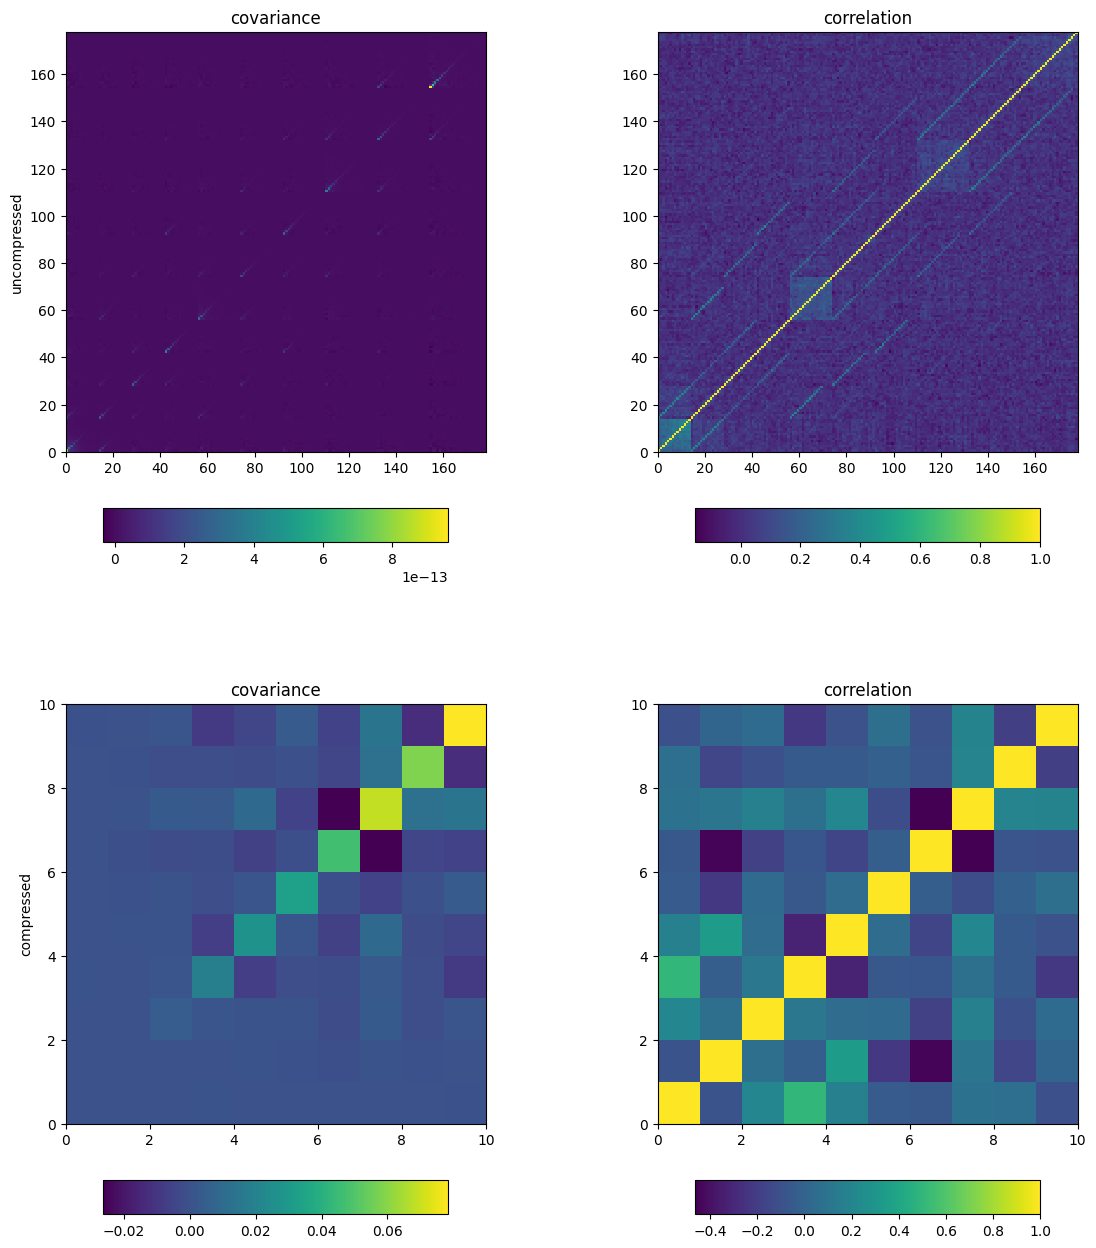

In [10]:
method_label = f"gaussian_likelihood"
label = "cls_" + probe_label + "_" + method_label

fidu_cov = np.cov(fidu_cls, rowvar=False)
fidu_corr = np.corrcoef(fidu_cls, rowvar=False)

# standardized
fidu_standard_cov = np.cov(fidu_standard_cls, rowvar=False)
fidu_standard_corr = np.corrcoef(fidu_standard_cls, rowvar=False)

# compressed
fidu_compressed_cov = np.cov(fidu_compressed_cls, rowvar=False)
fidu_compressed_corr = np.corrcoef(fidu_compressed_cls, rowvar=False)

# plot
fig, ax = plt.subplots(figsize=(14,16), ncols=2, nrows=2)

# uncompressed

# covariance
im = ax[0,0].pcolormesh(fidu_cov)
ax[0,0].set(title="covariance", ylabel="uncompressed")
ax[0,0].set_aspect("equal")

fig.colorbar(im, ax=ax[0,0], orientation="horizontal", shrink=0.7, pad=0.1, aspect=10)

# correlation
im = ax[0,1].pcolormesh(fidu_corr)
ax[0,1].set(title="correlation")
ax[0,1].set_aspect("equal")

fig.colorbar(im, ax=ax[0,1], orientation="horizontal", shrink=0.7, pad=0.1, aspect=10)

# compressed

# covariance
im = ax[1,0].pcolormesh(fidu_compressed_cov)
ax[1,0].set(title="covariance", ylabel="compressed")
ax[1,0].set_aspect("equal")

fig.colorbar(im, ax=ax[1,0], orientation="horizontal", shrink=0.7, pad=0.1, aspect=10)

# correlation
im = ax[1,1].pcolormesh(fidu_compressed_corr)
ax[1,1].set(title="correlation")
ax[1,1].set_aspect("equal")

fig.colorbar(im, ax=ax[1,1], orientation="horizontal", shrink=0.7, pad=0.1, aspect=10)

In [11]:
x_gauss_like = grid_theta

y_gauss_like = grid_standard_cls
cov_gauss_like = fidu_standard_cov
obs_gauss_like = obs_standard_cls

# y_gauss_like = grid_compressed_cls
# cov_gauss_like = fidu_compressed_cov
# obs_gauss_like = obs_compressed_cls

23-07-21 03:41:39 dense_emulat INF   Preprocessing scalers have been successfully fit 
Model: "model_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 4)]               0         
                                                                 
 tf.math.subtract_1 (TFOpLam  (None, 4)                0         
 bda)                                                            
                                                                 
 tf.math.truediv_1 (TFOpLamb  (None, 4)                0         
 da)                                                             
                                                                 
 dense_6 (Dense)             (None, 1024)              5120      
                                                                 
 dropout_5 (Dropout)         (None, 1024)              0         
                                      

epoch:  23%|██▎       | 229/1000 [00:24<01:28,  8.70it/s, loss=0.234, val_loss=0.0367, lr=1e-5]

Restoring model weights from the end of the best epoch: 130.


epoch:  23%|██▎       | 230/1000 [00:24<01:27,  8.79it/s, loss=0.234, val_loss=0.0369, lr=1e-5]

Epoch 230: early stopping


epoch:  23%|██▎       | 230/1000 [00:24<01:22,  9.33it/s, loss=0.234, val_loss=0.0369, lr=1e-5]


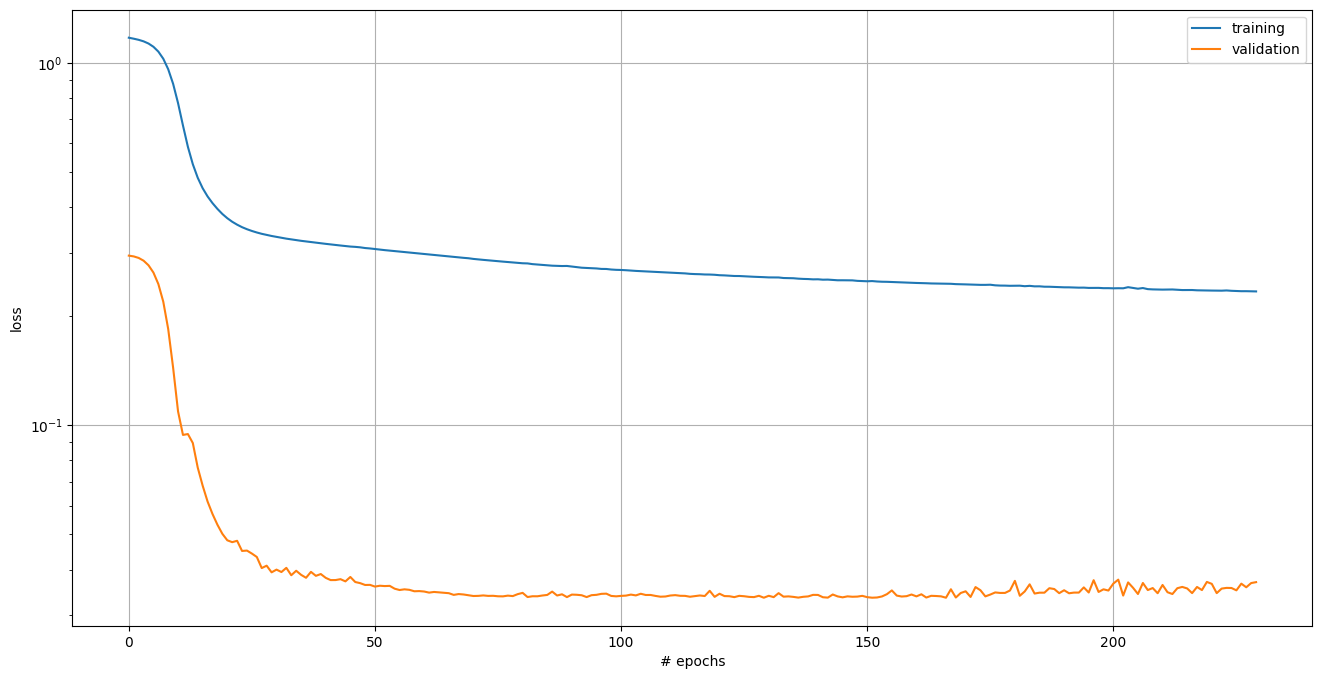

In [13]:
# f(x) = y
emu = DenseEmulator(
    x=tf.cast(x_gauss_like, dtype=tf.float32), 
    y=tf.cast(y_gauss_like, dtype=tf.float32),
    n_units=1024, 
    n_layers=5, 
    dropout_rate=0.0,
    learning_rate=1e-5,
)

# training
history = emu.fit(
    x=tf.cast(x_gauss_like, dtype=tf.float32), 
    y=tf.cast(y_gauss_like, dtype=tf.float32),
    validation_split=0.2, 
    batch_size=2499,
    epochs=1000,
    early_stopping_callback=True,
    learning_rate_callback=True,
)

# plot
fig, ax = plt.subplots(figsize=(16,8))

ax.plot(history.history["loss"], label="training")
ax.plot(history.history["val_loss"], label="validation")

ax.legend()
ax.set(xlabel="# epochs", ylabel="loss", yscale="log")
ax.grid(True)

23-07-21 00:50:39      mcmc.py INF   Initial values in prior: True 


100%|██████████| 1000/1000 [01:22<00:00, 12.14it/s]

23-07-21 00:52:10      mcmc.py WAR   Not saving the chain 


  0%|          | 0/6 [00:00<?, ?it/s]

  0%|          | 0/6 [00:00<?, ?it/s]

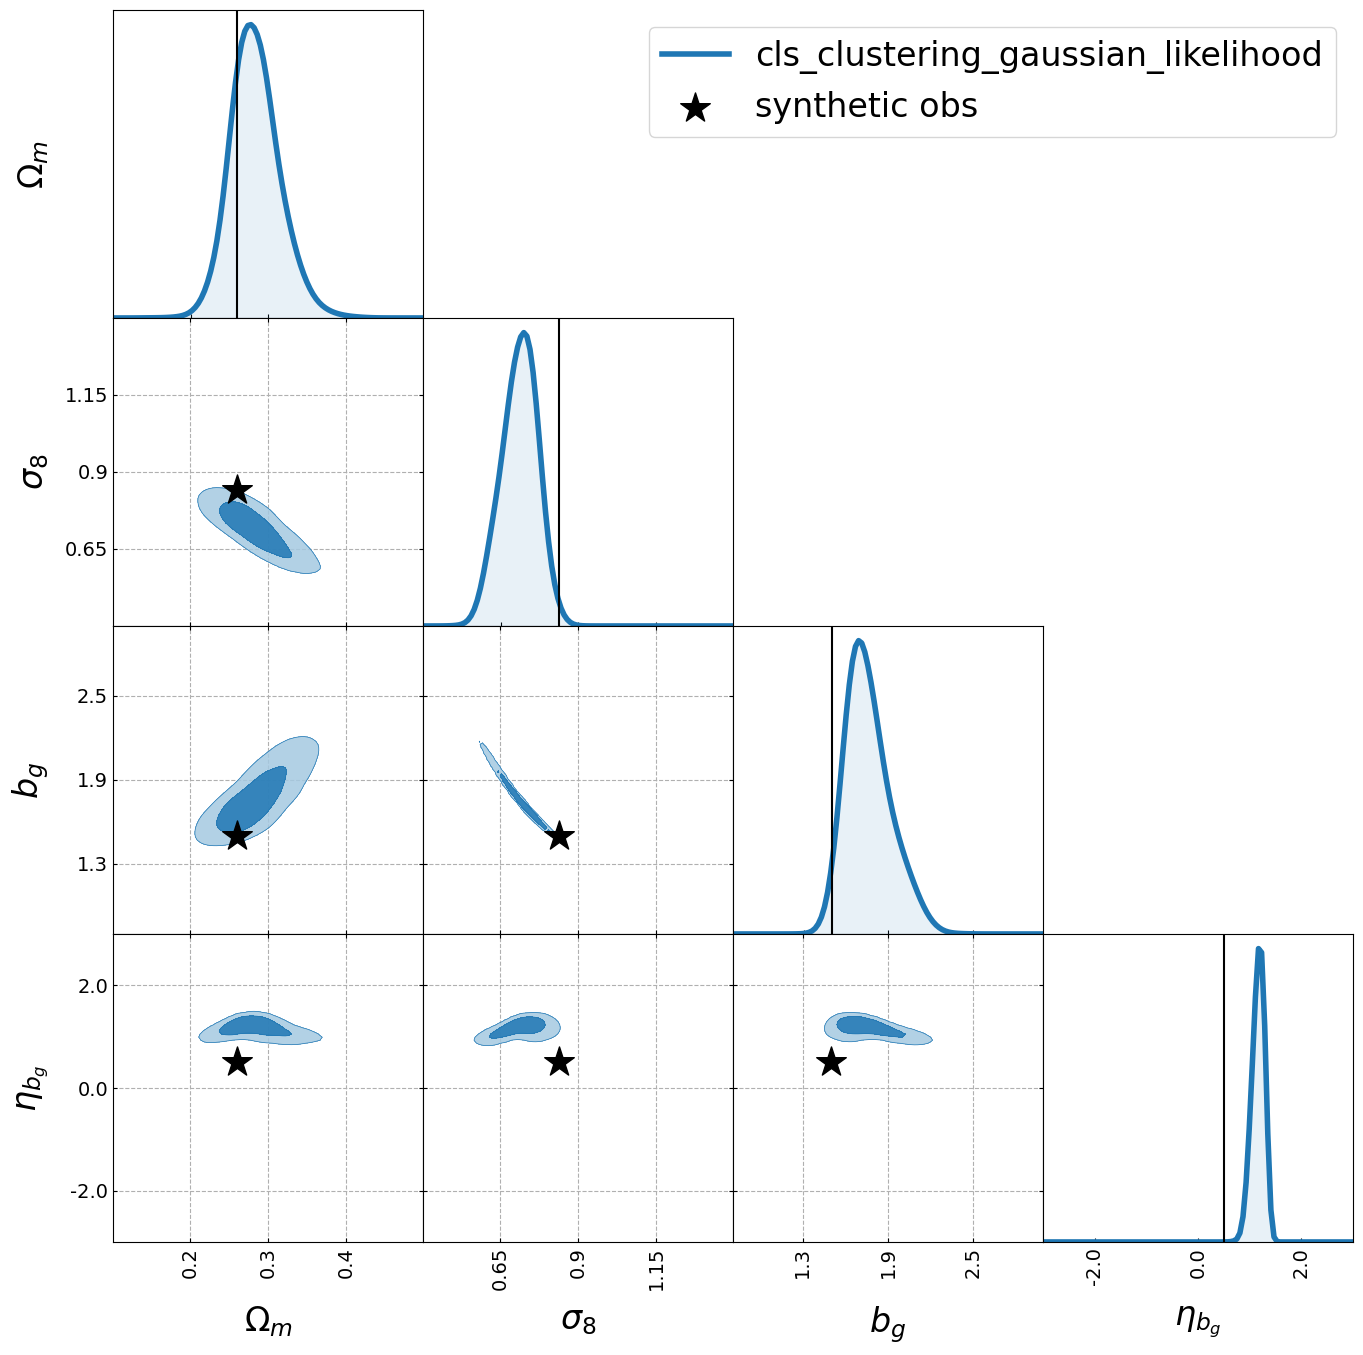

In [18]:
tf_cholesky = tf.linalg.cholesky(tf.cast(cov_gauss_like, dtype=tf.float32))
tf_pred = tf.cast(obs_gauss_like, dtype=tf.float32)

def log_likelihood(X): 
    # X = emu.scale_forward_x(X)
    normal = tfp.distributions.MultivariateNormalTriL(
        loc=emu(X), 
        scale_tril=tf_cholesky,
    )

    # evaluate the normal distribution
    log_prob = normal.log_prob(tf_pred)
    
    # enforce the prior
    log_prob = prior.log_posterior(X, log_prob, params=params, conf=None)

    return log_prob

chain = mcmc.run_emcee(
    log_likelihood,
    params,
    out_dir=None,
    label=label,
)

plotting.plot_chains(
    chain, 
    params, 
    out_dir=out_dir, 
    labels=label,
)